# 04B - Commerce Multi-Class Risk Model Hyperparameter Tuning

This notebook performs dedicated hyperparameter tuning for the **Sri Lankan A/L Commerce Risk Model** in the Smart Learning System.

This is a core project model because it supports:

- Student risk-level prediction
- Parent risk alerts
- Teacher weak-student detection
- Commerce-subject performance monitoring

## 1. Notebook Objectives

This notebook will:

- Load the processed Commerce Risk dataset created after the project was switched to Sri Lankan A/L Commerce context.
- Use Commerce subject features only.
- Exclude `Subject_Average` from the model input to prevent target-label leakage.
- Compare baseline Logistic Regression, Decision Tree and Random Forest models.
- Tune candidate models with `GridSearchCV`.
- Select the best tuned Commerce Risk model using balanced metrics.
- Export tuning results, best parameters, classification reports and confusion matrices.

In [21]:
from pathlib import Path
import json
import os
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mplconfig")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display as display_image

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

RANDOM_STATE = 42

## 2. Resolve Project Paths

In [22]:
def find_ml_root(start_path=Path.cwd()):
    current = start_path.resolve()
    for candidate in [current, *current.parents]:
        if candidate.name == "ml-model" and (candidate / "datasets").exists():
            return candidate
        nested = candidate / "ml-model"
        if nested.exists() and (nested / "datasets").exists():
            return nested
    raise FileNotFoundError("Could not locate ml-model directory. Run this notebook inside the project repository.")

ML_ROOT = find_ml_root()
PROCESSED_DIR = ML_ROOT / "datasets" / "processed"
FIGURES_DIR = ML_ROOT / "outputs" / "figures"
TUNING_DIR = ML_ROOT / "outputs" / "tuning"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TUNING_DIR.mkdir(parents=True, exist_ok=True)

COMMERCE_RISK_DATASET = PROCESSED_DIR / "commerce_risk_dataset.csv"
METADATA_PATH = PROCESSED_DIR / "preprocessing_metadata.json"

print("ML root:", ML_ROOT)
print("Commerce Risk dataset:", COMMERCE_RISK_DATASET)
print("Tuning directory:", TUNING_DIR)
print("Figures directory:", FIGURES_DIR)

ML root: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model
Commerce Risk dataset: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/datasets/processed/commerce_risk_dataset.csv
Tuning directory: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning
Figures directory: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures


## 3. Define Commerce Risk Features and Target

The generic `Math/English/Science` risk model was replaced with a Sri Lankan A/L Commerce version.

In [23]:
if METADATA_PATH.exists():
    metadata = json.loads(METADATA_PATH.read_text())
else:
    metadata = {}

commerce_features = [
    "Accounting_Score",
    "Business_Studies_Score",
    "Economics_Score",
    "Attendance_Percentage",
]
commerce_target = "risk_level"
expected_classes = ["High Risk", "Medium Risk", "Low Risk"]
leakage_columns = ["Subject_Average"]

print("Commerce features:", commerce_features)
print("Commerce target:", commerce_target)
print("Expected classes:", expected_classes)
print("Data leakage note:", metadata.get("data_leakage_prevention", "Pipeline transformations are fitted on training data only."))

Commerce features: ['Accounting_Score', 'Business_Studies_Score', 'Economics_Score', 'Attendance_Percentage']
Commerce target: risk_level
Expected classes: ['High Risk', 'Medium Risk', 'Low Risk']
Data leakage note: Scaling, fitted imputation, encoding objects and resampling are fitted only on the training split during model training.


## 4. Data Leakage Prevention

`Subject_Average` is excluded from model features because the risk label can be created from average score and attendance logic. Including it would make the model unrealistically easy and could leak target-label rules.

This notebook also fits imputation and scaling only inside model pipelines and cross-validation folds.

## 5. Load Commerce Risk Dataset

In [24]:
if not COMMERCE_RISK_DATASET.exists():
    raise FileNotFoundError(f"Missing dataset: {COMMERCE_RISK_DATASET}. Run 02_Data_Preprocessing.ipynb first.")

commerce_df = pd.read_csv(COMMERCE_RISK_DATASET)
print("Dataset shape:", commerce_df.shape)
display(commerce_df.head())

Dataset shape: (1800, 7)


,student_id,Accounting_Score,Business_Studies_Score,Economics_Score,Attendance_Percentage,Subject_Average,risk_level
0,COM0001,75.0,70.5,45.4,79.4,63.64,Medium Risk
1,COM0002,62.6,60.5,73.4,87.1,65.53,Low Risk
2,COM0003,82.7,80.0,80.0,71.5,80.91,Medium Risk
3,COM0004,82.4,70.6,81.9,70.4,78.30,Medium Risk
4,COM0005,79.0,61.4,78.7,56.3,73.04,Medium Risk


## 6. Validate Columns and Data Types

In [25]:
required_columns = commerce_features + [commerce_target]
missing_columns = [column for column in required_columns if column not in commerce_df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

available_leakage_columns = [column for column in leakage_columns if column in commerce_df.columns]

print("All required columns are available.")
print("Leakage-prone columns present but excluded:", available_leakage_columns)
display(pd.DataFrame({"Data Type": commerce_df[required_columns].dtypes.astype(str)}))

All required columns are available.
Leakage-prone columns present but excluded: ['Subject_Average']


,Data Type
Accounting_Score,float64
Business_Studies_Score,float64
Economics_Score,float64
Attendance_Percentage,float64
risk_level,str


## 7. Class Distribution and Current Dataset Limitation

The project expects three risk classes:

- High Risk
- Medium Risk
- Low Risk

The current processed dataset may not contain all expected classes. The notebook reports missing classes explicitly and tunes using the available classes.

In [26]:
target_counts = commerce_df[commerce_target].value_counts()
target_percentages = commerce_df[commerce_target].value_counts(normalize=True) * 100

class_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages.round(2),
})

display(class_summary)

available_classes = commerce_df[commerce_target].value_counts().index.tolist()
missing_expected_classes = [label for label in expected_classes if label not in available_classes]

print("Available classes:", available_classes)
print("Missing expected classes:", missing_expected_classes)

class_summary_path = TUNING_DIR / "commerce_risk_tuning_class_distribution.csv"
class_summary.to_csv(class_summary_path)
print("Saved:", class_summary_path)

,Count,Percentage
risk_level,,
Low Risk,666,37.0
Medium Risk,630,35.0
High Risk,504,28.0


Available classes: ['Low Risk', 'Medium Risk', 'High Risk']
Missing expected classes: []
Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/commerce_risk_tuning_class_distribution.csv


## 8. Feature and Target Separation

In [27]:
X = commerce_df[commerce_features].copy()
y = commerce_df[commerce_target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
display(X.head())

X shape: (1800, 4)
y shape: (1800,)


,Accounting_Score,Business_Studies_Score,Economics_Score,Attendance_Percentage
0,75.0,70.5,45.4,79.4
1,62.6,60.5,73.4,87.1
2,82.7,80.0,80.0,71.5
3,82.4,70.6,81.9,70.4
4,79.0,61.4,78.7,56.3


## 9. Train/Test Split

A stratified split keeps the available risk-class proportions similar in training and testing sets.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.DataFrame({
    "Split": ["Training", "Testing"],
    "Rows": [len(y_train), len(y_test)],
})

for label in available_classes:
    split_summary[label] = [int((y_train == label).sum()), int((y_test == label).sum())]

display(split_summary)

,Split,Rows,Low Risk,Medium Risk,High Risk
0,Training,1440,533,504,403
1,Testing,360,133,126,101


## 10. Helper Functions

In [29]:
def calculate_multiclass_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "Macro F1 Score": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "Weighted F1 Score": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }


def make_baseline_models():
    return {
        "Logistic Regression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced")),
        ]),
        "Decision Tree": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced", max_depth=5)),
        ]),
        "Random Forest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, class_weight="balanced")),
        ]),
    }


def make_tuning_grids():
    return {
        "Logistic Regression": (
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(max_iter=1500, random_state=RANDOM_STATE, class_weight="balanced")),
            ]),
            {
                "model__C": [0.1, 1.0, 10.0, 50.0],
                "model__solver": ["lbfgs", "liblinear"],
            },
        ),
        "Decision Tree": (
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced")),
            ]),
            {
                "model__criterion": ["gini", "entropy"],
                "model__max_depth": [2, 3, 5, 8, None],
                "model__min_samples_split": [2, 5, 10],
                "model__min_samples_leaf": [1, 2, 4],
            },
        ),
        "Random Forest": (
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("model", RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced")),
            ]),
            {
                "model__n_estimators": [100, 200, 300],
                "model__max_depth": [None, 5, 10],
                "model__min_samples_split": [2, 5],
                "model__min_samples_leaf": [1, 2],
                "model__max_features": ["sqrt", "log2"],
            },
        ),
    }


def save_confusion_matrix(y_true, y_pred, labels, title, output_path):
    matrix = confusion_matrix(y_true, y_pred, labels=labels)
    display_obj = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels)
    fig, ax = plt.subplots(figsize=(7, 6))
    display_obj.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(title)
    plt.xticks(rotation=20)
    plt.tight_layout()
    fig.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.close(fig)
    print("Saved:", output_path)
    display_image(Image(filename=str(output_path)))

## 11. Baseline Model Evaluation

In [30]:
baseline_rows = []
baseline_models = make_baseline_models()
baseline_predictions = {}

for model_name, model in baseline_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    baseline_predictions[model_name] = y_pred
    baseline_rows.append({
        "Model": model_name,
        "Version": "Baseline",
        **calculate_multiclass_metrics(y_test, y_pred),
    })

baseline_df = pd.DataFrame(baseline_rows).round(4)
display(baseline_df)

baseline_path = TUNING_DIR / "commerce_risk_baseline_scores.csv"
baseline_df.to_csv(baseline_path, index=False)
print("Saved:", baseline_path)

,Model,Version,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1 Score,Weighted F1 Score
0,Logistic Regression,Baseline,0.7333,0.7357,0.7358,0.7357,0.7357,0.7338
1,Decision Tree,Baseline,0.6889,0.6893,0.7104,0.6893,0.6951,0.6939
2,Random Forest,Baseline,0.7000,0.6954,0.7116,0.6954,0.7011,0.7025


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/commerce_risk_baseline_scores.csv


## 12. Hyperparameter Search Space

In [31]:
tuning_grids = make_tuning_grids()

for model_name, (_, param_grid) in tuning_grids.items():
    combinations = 1
    for values in param_grid.values():
        combinations *= len(values)
    print(f"{model_name}: {combinations} parameter combinations")

Logistic Regression: 8 parameter combinations
Decision Tree: 90 parameter combinations
Random Forest: 72 parameter combinations


## 13. Run GridSearchCV Tuning

The scoring metric is `balanced_accuracy`, because the Commerce Risk dataset is strongly imbalanced.

In [32]:
minimum_class_count = int(y_train.value_counts().min())
n_splits = min(5, minimum_class_count)
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

tuning_rows = []
tuned_models = {}
tuned_predictions = {}
all_cv_results = []

for model_name, (pipeline, param_grid) in tuning_grids.items():
    print("Running GridSearchCV:", model_name)
    search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring="balanced_accuracy",
        cv=cv,
        n_jobs=None,
        refit=True,
        return_train_score=True,
    )
    search.fit(X_train, y_train)

    tuned_model = search.best_estimator_
    y_pred = tuned_model.predict(X_test)

    tuned_models[model_name] = tuned_model
    tuned_predictions[model_name] = y_pred

    tuning_rows.append({
        "Model": model_name,
        "Version": "Tuned",
        "Best CV Balanced Accuracy": search.best_score_,
        "Best Parameters": json.dumps(search.best_params_),
        "CV Folds": n_splits,
        **calculate_multiclass_metrics(y_test, y_pred),
    })

    cv_results_df = pd.DataFrame(search.cv_results_)
    cv_results_df["Model"] = model_name
    all_cv_results.append(cv_results_df)

tuning_df = pd.DataFrame(tuning_rows).round(4)
display(tuning_df)

tuning_results_path = TUNING_DIR / "commerce_risk_tuning_results.csv"
tuning_df.to_csv(tuning_results_path, index=False)
print("Saved:", tuning_results_path)

cv_results_path = TUNING_DIR / "commerce_risk_tuning_cv_results.csv"
pd.concat(all_cv_results, ignore_index=True).to_csv(cv_results_path, index=False)
print("Saved:", cv_results_path)

Running GridSearchCV: Logistic Regression
Running GridSearchCV: Decision Tree
Running GridSearchCV: Random Forest


,Model,Version,Best CV Balanced Accuracy,Best Parameters,CV Folds,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1 Score,Weighted F1 Score
0,Logistic Regression,Tuned,0.7246,"{""model__C"": 0.1, ""model__solver"": ""lbfgs""}",5,0.7306,0.7324,0.7334,0.7324,0.7328,0.7312
1,Decision Tree,Tuned,0.6520,"{""model__criterion"": ""entropy"", ""model__max_de...",5,0.6833,0.6849,0.7047,0.6849,0.6905,0.6880
2,Random Forest,Tuned,0.6937,"{""model__max_depth"": null, ""model__max_feature...",5,0.7139,0.7131,0.7299,0.7131,0.7193,0.7172


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/commerce_risk_tuning_results.csv
Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/commerce_risk_tuning_cv_results.csv


## 14. Baseline vs Tuned Comparison

In [33]:
comparison_df = pd.concat([baseline_df, tuning_df], ignore_index=True, sort=False)
comparison_df = comparison_df.sort_values(
    by=["Balanced Accuracy", "Macro F1 Score", "Accuracy", "Weighted F1 Score"],
    ascending=False,
).reset_index(drop=True)

display(comparison_df)

comparison_path = TUNING_DIR / "commerce_risk_baseline_vs_tuned_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)
print("Saved:", comparison_path)

,Model,Version,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1 Score,Weighted F1 Score,Best CV Balanced Accuracy,Best Parameters,CV Folds
0,Logistic Regression,Baseline,0.7333,0.7357,0.7358,0.7357,0.7357,0.7338,NaN,NaN,NaN
1,Logistic Regression,Tuned,0.7306,0.7324,0.7334,0.7324,0.7328,0.7312,0.7246,"{""model__C"": 0.1, ""model__solver"": ""lbfgs""}",5.0
2,Random Forest,Tuned,0.7139,0.7131,0.7299,0.7131,0.7193,0.7172,0.6937,"{""model__max_depth"": null, ""model__max_feature...",5.0
3,Random Forest,Baseline,0.7000,0.6954,0.7116,0.6954,0.7011,0.7025,NaN,NaN,NaN
4,Decision Tree,Baseline,0.6889,0.6893,0.7104,0.6893,0.6951,0.6939,NaN,NaN,NaN
5,Decision Tree,Tuned,0.6833,0.6849,0.7047,0.6849,0.6905,0.6880,0.6520,"{""model__criterion"": ""entropy"", ""model__max_de...",5.0


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/commerce_risk_baseline_vs_tuned_comparison.csv


## 15. Select Best Tuned Model

The best tuned model is selected using:

1. Balanced Accuracy
2. Macro F1 Score
3. Accuracy
4. Cross-validation score

In [34]:
tuned_only = tuning_df.sort_values(
    by=["Balanced Accuracy", "Macro F1 Score", "Accuracy", "Best CV Balanced Accuracy"],
    ascending=False,
).reset_index(drop=True)

best_model_name = tuned_only.iloc[0]["Model"]
best_model = tuned_models[best_model_name]
best_predictions = tuned_predictions[best_model_name]
best_params = json.loads(tuned_only.iloc[0]["Best Parameters"])

print("Best tuned Commerce Risk model:", best_model_name)
print("Best parameters:", best_params)
display(tuned_only.head(1))

Best tuned Commerce Risk model: Logistic Regression
Best parameters: {'model__C': 0.1, 'model__solver': 'lbfgs'}


,Model,Version,Best CV Balanced Accuracy,Best Parameters,CV Folds,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1 Score,Weighted F1 Score
0,Logistic Regression,Tuned,0.7246,"{""model__C"": 0.1, ""model__solver"": ""lbfgs""}",5,0.7306,0.7324,0.7334,0.7324,0.7328,0.7312


## 16. Best Tuned Model Classification Report

In [35]:
report_text = classification_report(y_test, best_predictions, zero_division=0)
print(report_text)

report_dict = classification_report(y_test, best_predictions, output_dict=True, zero_division=0)
report_path = TUNING_DIR / "commerce_risk_best_tuned_classification_report.json"
report_path.write_text(json.dumps(report_dict, indent=2))
print("Saved:", report_path)

              precision    recall  f1-score   support

   High Risk       0.77      0.77      0.77       101
    Low Risk       0.80      0.78      0.79       133
 Medium Risk       0.63      0.64      0.64       126

    accuracy                           0.73       360
   macro avg       0.73      0.73      0.73       360
weighted avg       0.73      0.73      0.73       360

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/commerce_risk_best_tuned_classification_report.json


## 17. Best Tuned Model Confusion Matrix

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/commerce_risk_best_tuned_confusion_matrix.png


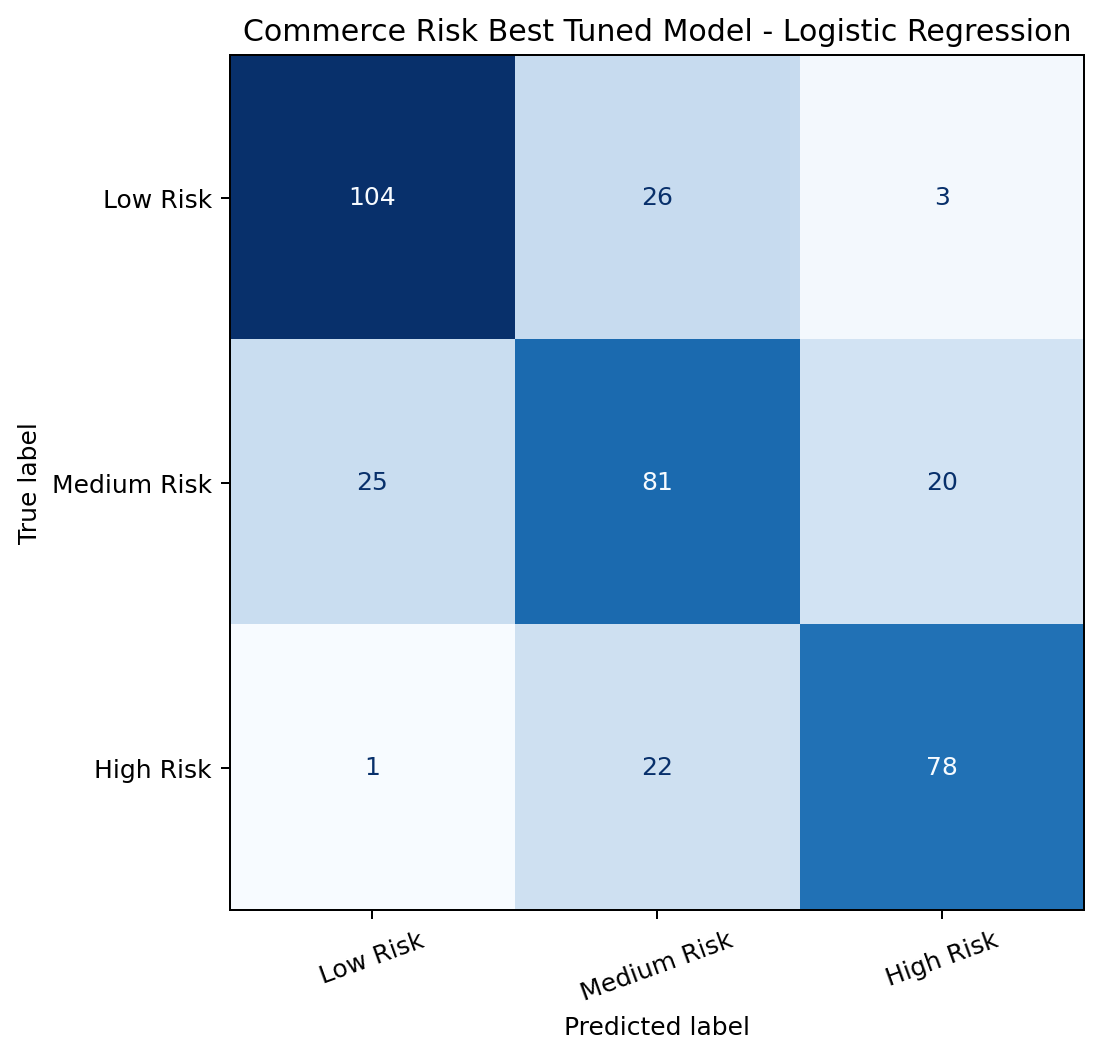

In [36]:
best_cm_path = FIGURES_DIR / "commerce_risk_best_tuned_confusion_matrix.png"
save_confusion_matrix(
    y_test,
    best_predictions,
    available_classes,
    f"Commerce Risk Best Tuned Model - {best_model_name}",
    best_cm_path,
)

## 18. Confusion Matrices for All Tuned Models

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/commerce_risk_tuned_logistic_regression_confusion_matrix.png


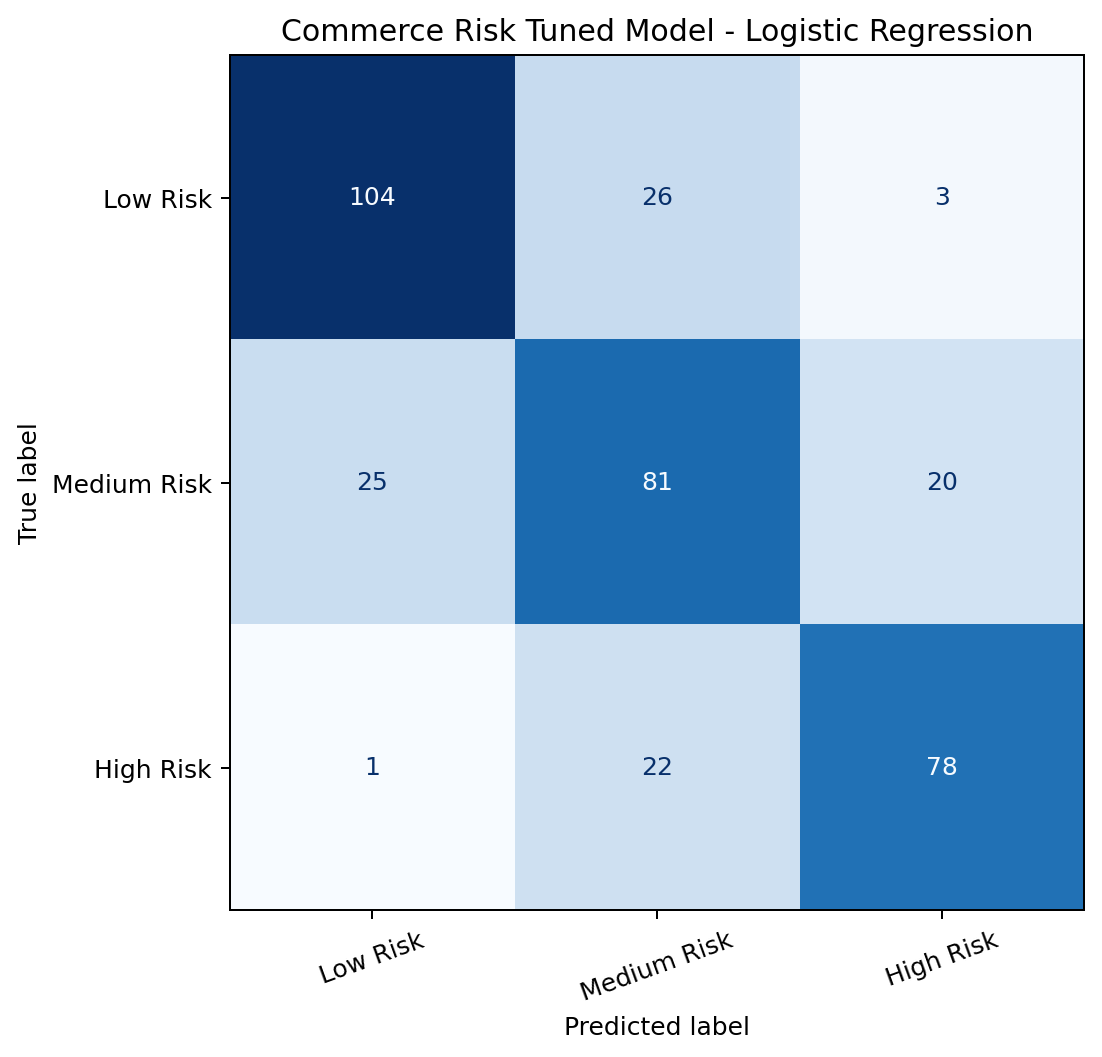

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/commerce_risk_tuned_decision_tree_confusion_matrix.png


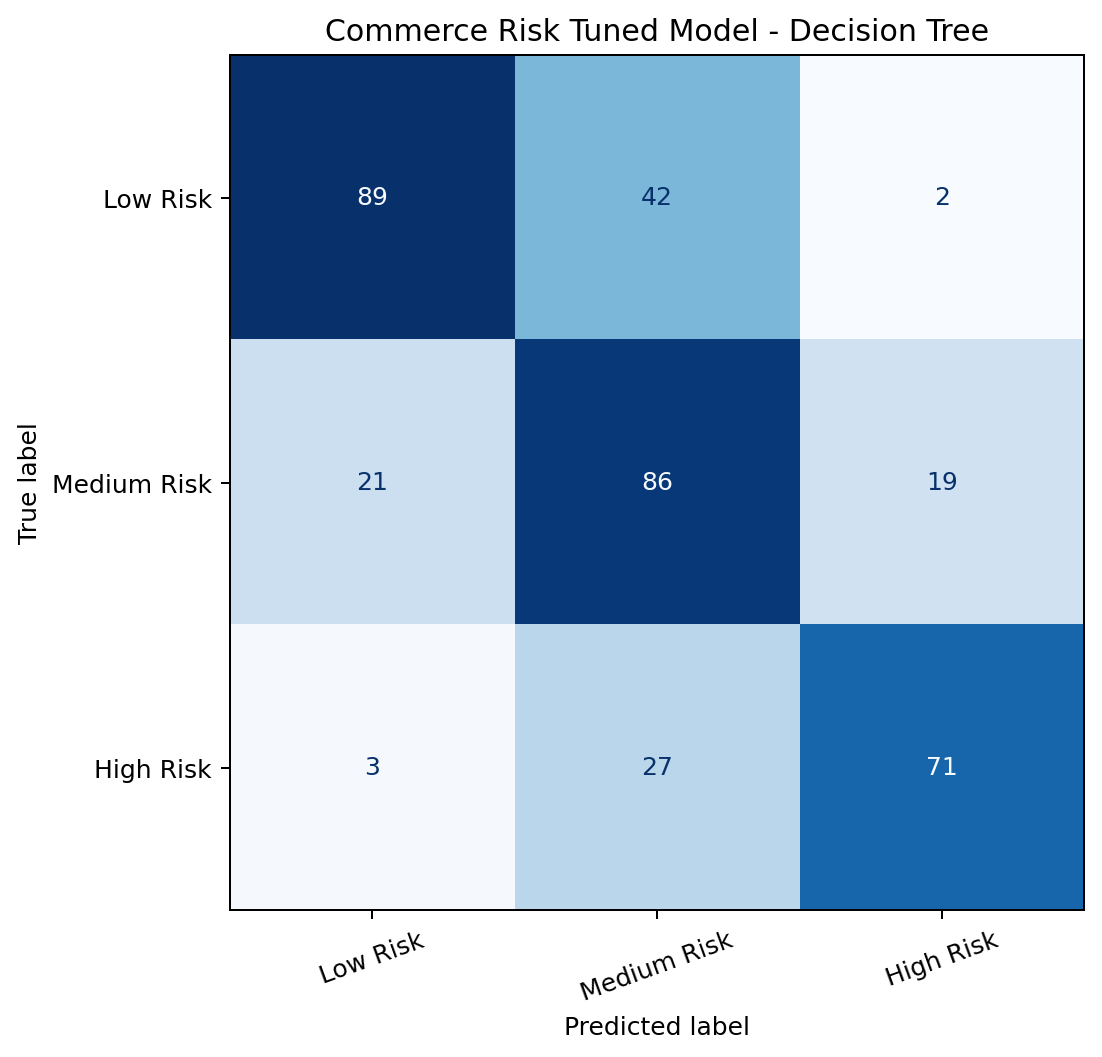

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/commerce_risk_tuned_random_forest_confusion_matrix.png


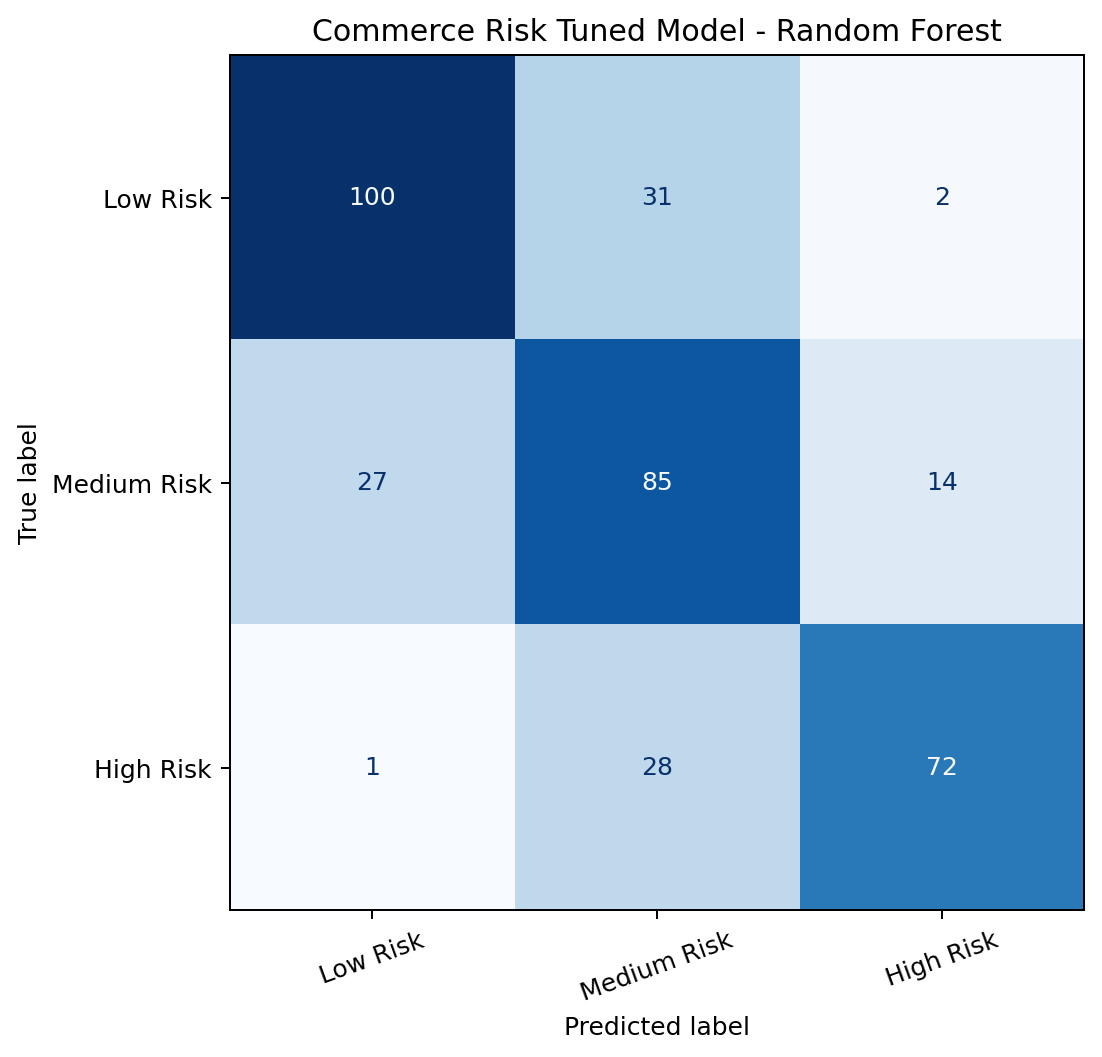

In [37]:
for model_name, y_pred in tuned_predictions.items():
    safe_name = model_name.lower().replace(" ", "_")
    output_path = FIGURES_DIR / f"commerce_risk_tuned_{safe_name}_confusion_matrix.png"
    save_confusion_matrix(
        y_test,
        y_pred,
        available_classes,
        f"Commerce Risk Tuned Model - {model_name}",
        output_path,
    )

## 19. Feature Importance / Coefficient Analysis

In [38]:
importance_rows = []

for model_name, pipeline in tuned_models.items():
    model_step = pipeline.named_steps["model"]
    if hasattr(model_step, "feature_importances_"):
        values = model_step.feature_importances_
        importance_type = "feature_importance"
    elif hasattr(model_step, "coef_"):
        values = np.mean(np.abs(model_step.coef_), axis=0)
        importance_type = "mean_absolute_coefficient"
    else:
        continue

    for feature, value in zip(commerce_features, values):
        importance_rows.append({
            "Model": model_name,
            "Importance Type": importance_type,
            "Feature": feature,
            "Value": float(value),
        })

importance_df = pd.DataFrame(importance_rows).sort_values(["Model", "Value"], ascending=[True, False])
display(importance_df.round(4))

importance_path = TUNING_DIR / "commerce_risk_tuned_feature_importance.csv"
importance_df.to_csv(importance_path, index=False)
print("Saved:", importance_path)

,Model,Importance Type,Feature,Value
7,Decision Tree,feature_importance,Attendance_Percentage,0.3479
4,Decision Tree,feature_importance,Accounting_Score,0.3014
6,Decision Tree,feature_importance,Economics_Score,0.1992
5,Decision Tree,feature_importance,Business_Studies_Score,0.1516
3,Logistic Regression,mean_absolute_coefficient,Attendance_Percentage,0.8251
2,Logistic Regression,mean_absolute_coefficient,Economics_Score,0.5030
0,Logistic Regression,mean_absolute_coefficient,Accounting_Score,0.4656
1,Logistic Regression,mean_absolute_coefficient,Business_Studies_Score,0.4090
11,Random Forest,feature_importance,Attendance_Percentage,0.3128
8,Random Forest,feature_importance,Accounting_Score,0.2574


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/commerce_risk_tuned_feature_importance.csv


## 20. Best Parameter Table

In [39]:
best_parameter_rows = [
    {"Model": best_model_name, "Parameter": parameter, "Value": value}
    for parameter, value in best_params.items()
]

best_parameters_df = pd.DataFrame(best_parameter_rows)
display(best_parameters_df)

best_parameters_path = TUNING_DIR / "commerce_risk_best_tuned_parameters.csv"
best_parameters_df.to_csv(best_parameters_path, index=False)
print("Saved:", best_parameters_path)

,Model,Parameter,Value
0,Logistic Regression,model__C,0.1
1,Logistic Regression,model__solver,lbfgs


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/commerce_risk_best_tuned_parameters.csv


## 21. Documentation Summary

In [40]:
summary = {
    "notebook": "04B_Multi_Class_Tuning.ipynb",
    "model_purpose": "Sri Lankan A/L Commerce student risk-level prediction",
    "dataset": str(COMMERCE_RISK_DATASET),
    "rows": int(commerce_df.shape[0]),
    "features": commerce_features,
    "target": commerce_target,
    "expected_classes": expected_classes,
    "available_classes": available_classes,
    "missing_expected_classes": missing_expected_classes,
    "excluded_leakage_columns": available_leakage_columns,
    "candidate_models": list(tuning_grids.keys()),
    "best_tuned_model": best_model_name,
    "best_parameters": best_params,
    "selection_metric": "Balanced Accuracy with Macro F1 and Accuracy as supporting metrics",
    "random_state": RANDOM_STATE,
    "data_leakage_prevention": "Subject_Average is excluded and pipeline transformations are fitted inside training folds only.",
    "tuning_results_file": str(tuning_results_path),
    "comparison_file": str(comparison_path),
    "classification_report_file": str(report_path),
    "confusion_matrix_file": str(best_cm_path),
}

summary_path = TUNING_DIR / "commerce_risk_tuning_summary.json"
summary_path.write_text(json.dumps(summary, indent=2))
print("Saved:", summary_path)

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/tuning/commerce_risk_tuning_summary.json


## 23. Final Conclusion

This notebook completed dedicated hyperparameter tuning for the Commerce Risk Model. The model uses Sri Lankan A/L Commerce features: Accounting, Business Studies, Economics and Attendance.

The notebook explicitly excluded `Subject_Average` to reduce leakage risk. Logistic Regression, Decision Tree and Random Forest models were tuned using stratified cross-validation and balanced accuracy.

The current processed dataset contains only the available risk classes shown above. If the final dataset later includes all three expected classes, this notebook can be rerun without changing the workflow.